<a href="https://colab.research.google.com/github/leah-mogotsi/Time-Series-Analysis-Forecasting/blob/main/Project_3_Leah_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **COVID-19 Time Series Analysis**

---
**Dataset source:** [Dataset_link]((https://github.com/CSSEGISandData/COVID-19/tree/master/csse_covid_19_data/csse_covid_19_time_series))

**Scope:** United States — County and State Level Analysis  

## **1. PROBLEM STATEMENT**

* **Problem 1 — Progression**
How did COVID-19 cases and deaths progress over time at a national level?


* **Problem 2 — Regional Identification**
Which US states were most severely affected?

* **Problem 3 — Actionable Insight**
During which time periods did cases and deaths accelerate the fastest?





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **1. EXPLORATORY DATA ANALYSIS (EDA)**

In [2]:
confirmed_cases = pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_US.csv")

deaths_df = pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_US.csv")

print(confirmed_cases.shape)  # should show (3342, 1155)
print(deaths_df.shape)        # should show (3342, 1156)

(3342, 1154)
(3342, 1155)


Each file has 3342 rows and approximately 1155 columns.

 **Separating Identifier Columns from Date Columns**

Our dataframe has two completely different types of columns mixed together:

**Identifier columns** — these describe WHERE the data comes from:
UID, iso2, iso3, Province_State, Country_Region, Lat, Long_ etc.

**Date columns** — these contain the actual case/death counts we want to analyse:
1/22/20, 1/23/20, 1/24/20 ... all the way to 3/9/23

Every step that follows — plotting trends, calculating rolling averages,
running the ARIMA model — only makes sense on the DATE columns.

If we accidentally included Province_State or Latitude in a calculation,
Python would either crash or produce meaningless results.

So here we create two clearly labelled lists:
- id_cols → the identifier columns to IGNORE in calculations
- date_cols → the date columns to USE in calculations

In [3]:
# Confirmed has no Population column
id_cols_confirmed = ["UID", "iso2", "iso3", "code3", "FIPS", "Admin2",
                     "Province_State", "Country_Region", "Lat", "Long_",
                     "Combined_Key"]

# Deaths has an extra Population column
id_cols_deaths = ["UID", "iso2", "iso3", "code3", "FIPS", "Admin2",
                  "Province_State", "Country_Region", "Lat", "Long_",
                  "Combined_Key", "Population"]

# Everything else is a date column
date_cols_confirmed = [col for col in confirmed_cases.columns if col not in id_cols_confirmed]
date_cols_deaths = [col for col in deaths_df.columns if col not in id_cols_deaths]

print("First date:", date_cols_deaths[0])
print("Last date:", date_cols_deaths[-1])
print("Total date columns:", len(date_cols_deaths))

First date: 1/22/20
Last date: 3/9/23
Total date columns: 1143


**Exploring Confirmed Cases Dataset**

In [4]:
confirmed_cases.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,19732,19759,19759,19759,19759,19759,19759,19759,19790,19790
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,69641,69767,69767,69767,69767,69767,69767,69767,69860,69860
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,7451,7474,7474,7474,7474,7474,7474,7474,7485,7485
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,8067,8087,8087,8087,8087,8087,8087,8087,8091,8091
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,18616,18673,18673,18673,18673,18673,18673,18673,18704,18704


In [5]:
print(confirmed_cases.columns.tolist())

['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Lat', 'Long_', 'Combined_Key', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20', '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20', '3/22/20', '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20', '3/28/20', '3/29/20', '3/30/20', '3/31/20', '4/1/20', '4/2/20', '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20', '4/8/20', '4/9/20', '4/10/20', '4/11/20', '4/12/20', '4/13/

In [6]:
confirmed_cases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3342 entries, 0 to 3341
Columns: 1154 entries, UID to 3/9/23
dtypes: float64(3), int64(1145), object(6)
memory usage: 29.4+ MB


In [7]:
# Get date columns
date_cols_confirmed = [col for col in confirmed_cases.columns if col not in id_cols_confirmed]

# Convert to numeric
confirmed_cases[date_cols_confirmed] = confirmed_cases[date_cols_confirmed].apply(pd.to_numeric, errors='coerce')

# Verify
confirmed_cases[date_cols_confirmed].describe()

confirmed_cases.describe()

,UID,code3,FIPS,Lat,Long_,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
count,3.342000e+03,3342.000000,3332.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,...,3.342000e+03,3.342000e+03,3.342000e+03,3.342000e+03,3.342000e+03,3.342000e+03,3.342000e+03,3.342000e+03,3.342000e+03,3.342000e+03
mean,8.342992e+07,834.494913,33043.078932,36.721617,-88.642045,0.000299,0.000299,0.000598,0.000598,0.001496,...,3.095256e+04,3.097961e+04,3.099634e+04,3.101397e+04,3.101461e+04,3.101346e+04,3.101602e+04,3.102660e+04,3.104601e+04,3.106005e+04
std,4.314076e+06,36.487378,18648.808931,9.079322,21.776287,0.017298,0.017298,0.024459,0.024459,0.038656,...,1.080476e+05,1.081128e+05,1.081972e+05,1.083087e+05,1.083093e+05,1.083090e+05,1.083152e+05,1.083322e+05,1.083601e+05,1.084494e+05
min,1.600000e+01,16.000000,60.000000,-14.271000,-174.159600,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.401811e+07,840.000000,19076.500000,33.896803,-97.803595,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.911000e+03,2.916250e+03,2.920250e+03,2.920250e+03,2.920250e+03,2.920250e+03,2.920250e+03,2.923000e+03,2.917500e+03,2.917500e+03
50%,8.402921e+07,840.000000,31012.000000,38.005610,-89.488865,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.707000e+03,7.713000e+03,7.724500e+03,7.724500e+03,7.724500e+03,7.724500e+03,7.724500e+03,7.735500e+03,7.735500e+03,7.750000e+03
75%,8.404612e+07,840.000000,47129.500000,41.579255,-82.313398,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.025800e+04,2.030300e+04,2.030375e+04,2.031275e+04,2.031275e+04,2.031275e+04,2.031950e+04,2.033450e+04,2.034500e+04,2.034875e+04
max,8.410000e+07,850.000000,99999.000000,69.314792,145.673900,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.697797e+06,3.697797e+06,3.704034e+06,3.705381e+06,3.705381e+06,3.705381e+06,3.705381e+06,3.705381e+06,3.705381e+06,3.710586e+06


In [8]:
confirmed_cases.isnull().sum()

,0
UID,0
iso2,0
iso3,0
code3,0
FIPS,10
...,...
3/5/23,0
3/6/23,0
3/7/23,0
3/8/23,0


**Missing Data**

The confirmed cases dataset contained 10 missing values in the FIPS column,
corresponding to unassigned regions where cases could not be attributed to
a specific county. Since FIPS is not used in any analysis, these missing
values were left as is and do not affect the results.

All date columns contained no missing values after numeric conversion.

**Exploring Deaths Dataset**

In [9]:
deaths_df.head()

,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,84001001,US,USA,840,1001.0,Autauga,Alabama,US,32.539527,-86.644082,...,230,232,232,232,232,232,232,232,232,232
1,84001003,US,USA,840,1003.0,Baldwin,Alabama,US,30.727750,-87.722071,...,724,726,726,726,726,726,726,726,727,727
2,84001005,US,USA,840,1005.0,Barbour,Alabama,US,31.868263,-85.387129,...,103,103,103,103,103,103,103,103,103,103
3,84001007,US,USA,840,1007.0,Bibb,Alabama,US,32.996421,-87.125115,...,109,109,109,109,109,109,109,109,109,109
4,84001009,US,USA,840,1009.0,Blount,Alabama,US,33.982109,-86.567906,...,261,261,261,261,261,261,261,261,261,261


In [10]:
print(deaths_df.columns.tolist())

['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Lat', 'Long_', 'Combined_Key', 'Population', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20', '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20', '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20', '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20', '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20', '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20', '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20', '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20', '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20', '3/22/20', '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20', '3/28/20', '3/29/20', '3/30/20', '3/31/20', '4/1/20', '4/2/20', '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20', '4/8/20', '4/9/20', '4/10/20', '4/11/20', '4/

In [11]:
deaths_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3342 entries, 0 to 3341
Columns: 1155 entries, UID to 3/9/23
dtypes: float64(3), int64(1146), object(6)
memory usage: 29.4+ MB


In [12]:
deaths_df.isnull().sum()

,0
UID,0
iso2,0
iso3,0
code3,0
FIPS,10
...,...
3/5/23,0
3/6/23,0
3/7/23,0
3/8/23,0


**Missing Data**

The deaths dataset contained 10 missing values in the FIPS column,
corresponding to unassigned regions where cases could not be attributed to
a specific county. Since FIPS is not used in any analysis, these missing
values were left as is and do not affect the results.

All date columns contained no missing values after numeric conversion.

In [13]:
deaths_df[date_cols_deaths].describe()

,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
count,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,...,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000,3342.000000
mean,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,0.000299,...,335.103830,335.397068,335.624776,335.776481,335.778576,335.767205,335.781269,335.881508,336.099940,336.276481
std,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,0.017298,...,1103.909631,1104.435933,1105.572242,1105.748480,1105.751727,1105.746239,1105.772895,1105.924446,1106.230834,1107.369648
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,39.000000,39.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,245.750000,245.750000,245.750000,246.000000,246.000000,246.000000,246.000000,246.750000,246.750000,246.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,35366.000000,35366.000000,35453.000000,35453.000000,35453.000000,35453.000000,35453.000000,35453.000000,35453.000000,35545.000000


**Deaths**

The early date columns (January 2020) show a mean of nearly zero and a max
of 1.0, confirming that COVID-19 deaths were extremely rare in the US at the
start of the pandemic. The 25%, 50% and 75% percentiles are all zero for early
dates, meaning the vast majority of counties had zero deaths in January 2020.

This is expected, because the first confirmed US COVID-19 death was not recorded
until late February 2020. The increasing values towards the later columns
(visible in the truncated right side) reflect the escalation of the pandemic
over time.

**Descriptive Statistics**

We run .describe() separately on the date columns of both dataframes to get
a statistical summary of the confirmed cases and death counts over time. We isolate the
date columns specifically because the identifier columns (Province_State,
Country_Region etc.) are text-based and would produce meaningless statistics.

## **2. DATA VISUALIZATION**

/tmp/ipykernel_255/2353795577.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  national_confirmed.index = pd.to_datetime(national_confirmed.index)
/tmp/ipykernel_255/2353795577.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  national_deaths.index = pd.to_datetime(national_deaths.index)


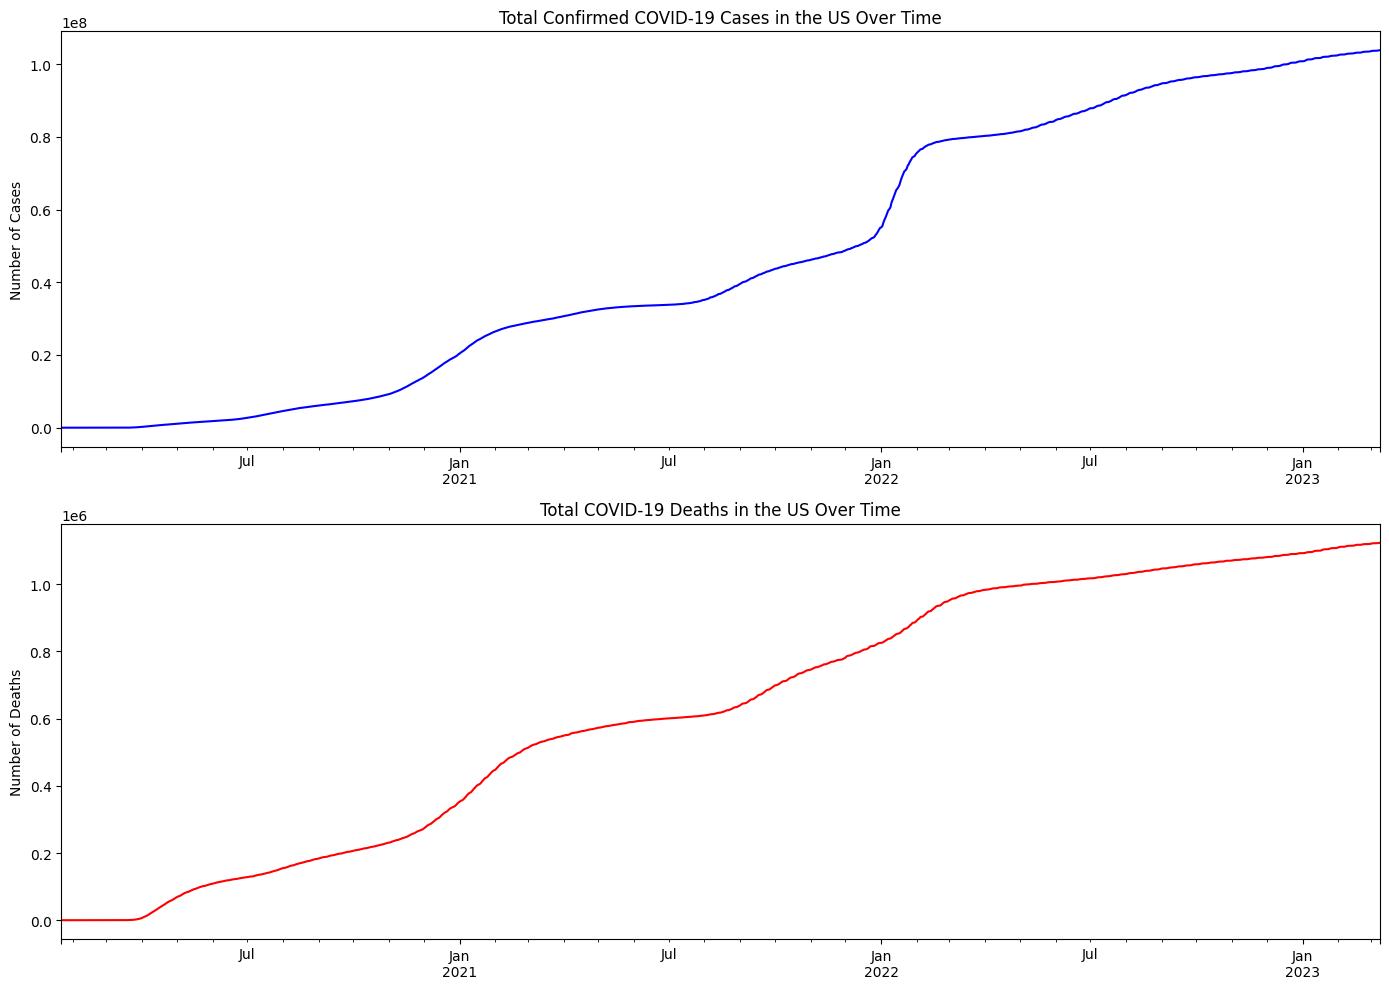

In [14]:
# Add up all counties to get one national number per day
national_confirmed = confirmed_cases[date_cols_confirmed].sum()
national_deaths = deaths_df[date_cols_deaths].sum()

# Convert date labels from text to real dates
national_confirmed.index = pd.to_datetime(national_confirmed.index)
national_deaths.index = pd.to_datetime(national_deaths.index)

# Plot both
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

national_confirmed.plot(ax=axes[0], color='blue')
axes[0].set_title("Total Confirmed COVID-19 Cases in the US Over Time")
axes[0].set_ylabel("Number of Cases")

national_deaths.plot(ax=axes[1], color='red')
axes[1].set_title("Total COVID-19 Deaths in the US Over Time")
axes[1].set_ylabel("Number of Deaths")

plt.tight_layout()
plt.show()

## **3. FINDINGS**

**National COVID-19 Trends**

Both confirmed cases and deaths show a clear upward trend from 2020 to 2023
with distinct waves. The most notable spike in cases occurred around January 2022
(Omicron variant), however deaths did not rise as sharply during this period,
suggesting vaccines were effective in reducing fatalities. By early 2023
both curves begin to flatten, indicating the pandemic was winding down.

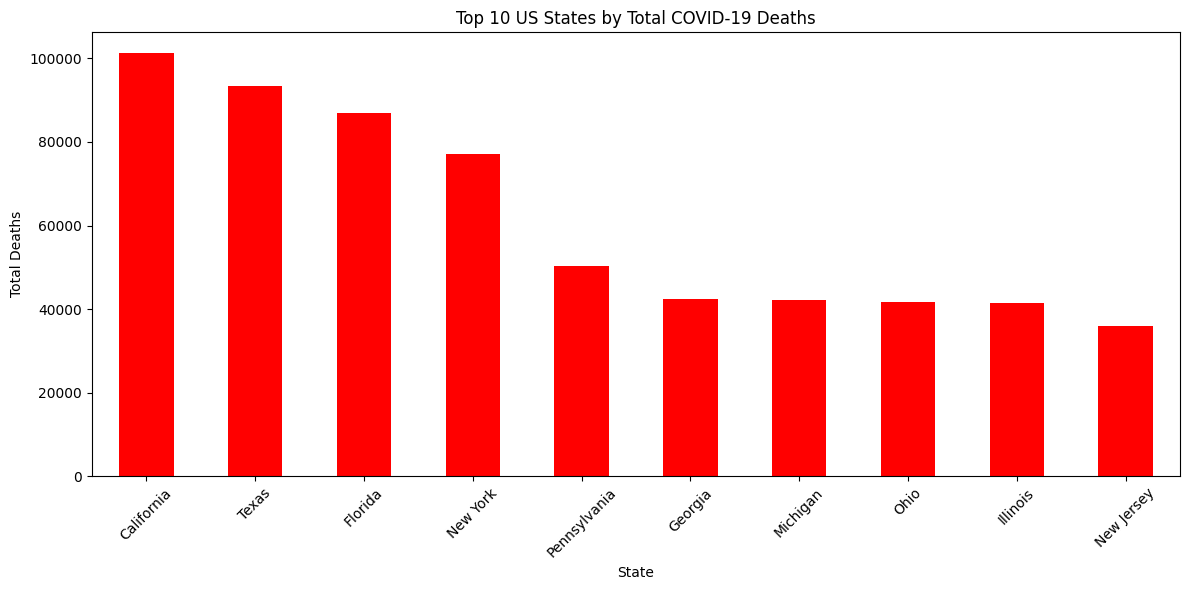


Top 10 States by Total Deaths:
Province_State
California      101159
Texas            93390
Florida          86850
New York         77157
Pennsylvania     50398
Georgia          42489
Michigan         42205
Ohio             41796
Illinois         41496
New Jersey       36015
Name: 3/9/23, dtype: int64


In [15]:
# Group all counties by state and add them up
state_deaths = deaths_df.groupby("Province_State")[date_cols_deaths].sum()

# Get the last date column = most recent total per state
last_date = date_cols_deaths[-1]
state_totals = state_deaths[last_date].sort_values(ascending=False)

# Bar chart
plt.figure(figsize=(12, 6))
state_totals.head(10).plot(kind='bar', color='red')
plt.title("Top 10 US States by Total COVID-19 Deaths")
plt.ylabel("Total Deaths")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nTop 10 States by Total Deaths:")
print(state_totals.head(10))

**Regional Differences**

California recorded the highest total deaths (~101,000), followed by Texas
and Florida. All top 10 states are among the most populous in the US,
confirming that population density was a key driver of pandemic severity.

/tmp/ipykernel_255/2440903254.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ny_deaths.index = pd.to_datetime(ny_deaths.index)


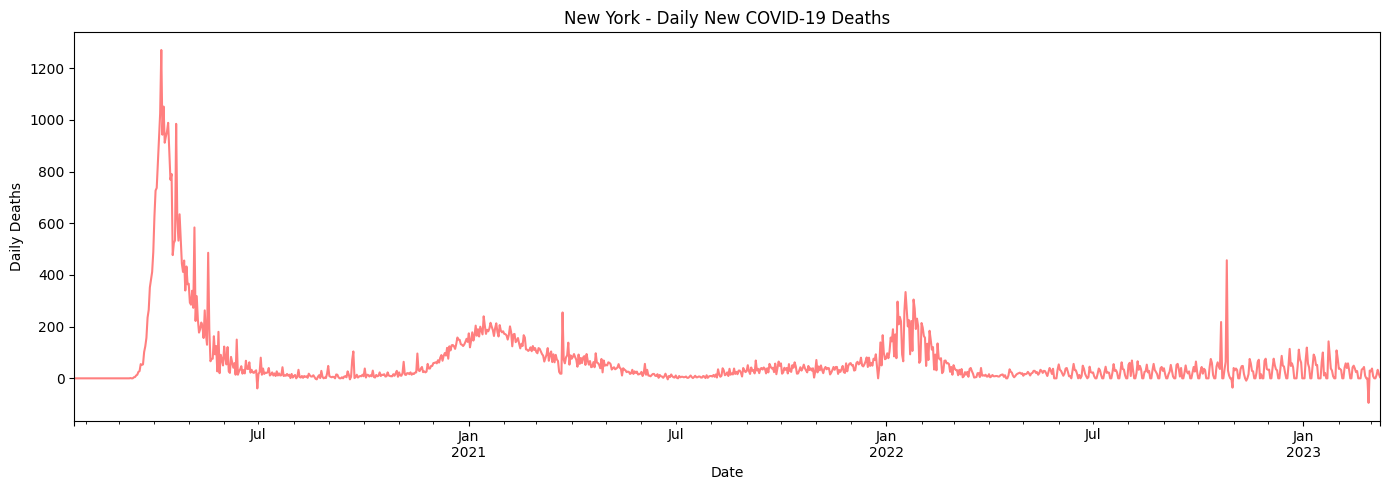

In [16]:
# Filter to New York rows only
ny_deaths = deaths_df[deaths_df["Province_State"] == "New York"]

# Add up all NY counties into one total per day
ny_deaths = ny_deaths[date_cols_deaths].sum()

# Convert dates
ny_deaths.index = pd.to_datetime(ny_deaths.index)

# Convert cumulative to daily new deaths
ny_daily_deaths = ny_deaths.diff().fillna(0)

# Plot daily deaths
plt.figure(figsize=(14, 5))
ny_daily_deaths.plot(color='red', alpha=0.5)
plt.title("New York - Daily New COVID-19 Deaths")
plt.ylabel("Daily Deaths")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

**Daily Deaths (New York)**

New York was the epicentre of the first wave, peaking at over 1,200 daily
deaths in Spring 2020. Subsequent waves were smaller due to growing immunity
and vaccination. Daily deaths approach zero by 2023.

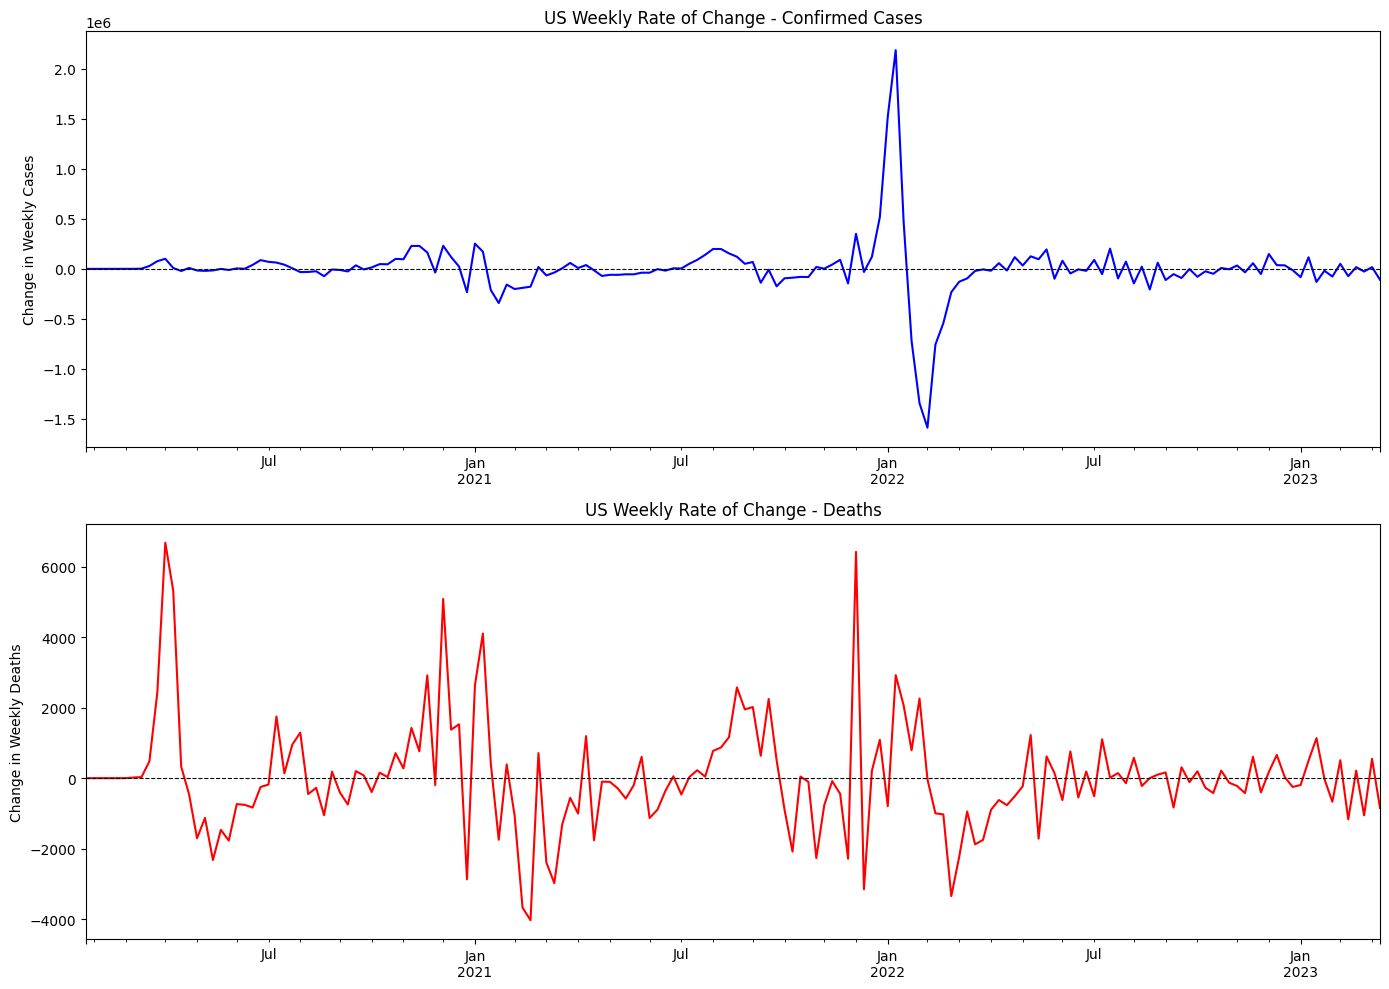

In [19]:
# ============================================================
# WEEKLY RATE OF CHANGE
# We resample the daily data into weekly totals
# .resample("W") groups data by week and .sum() adds them up
# .diff() then calculates the change from one week to the next
# ============================================================

# National daily deaths converted to weekly
national_daily_deaths = national_deaths.diff().fillna(0)
weekly_deaths = national_daily_deaths.resample("W").sum()
weekly_deaths_change = weekly_deaths.diff().fillna(0)

# National daily cases converted to weekly
national_daily_cases = national_confirmed.diff().fillna(0)
weekly_cases = national_daily_cases.resample("W").sum()
weekly_cases_change = weekly_cases.diff().fillna(0)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

weekly_cases_change.plot(ax=axes[0], color='blue')
axes[0].set_title("US Weekly Rate of Change - Confirmed Cases")
axes[0].set_ylabel("Change in Weekly Cases")
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

weekly_deaths_change.plot(ax=axes[1], color='red')
axes[1].set_title("US Weekly Rate of Change - Deaths")
axes[1].set_ylabel("Change in Weekly Deaths")
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

**Weekly Rate of Change**

**Confirmed Cases (blue):**
The most dramatic spike occurred around January 2022, coinciding with the
Omicron variant — weekly cases increased by over 2 million in a single week
before dropping sharply. Outside of this period, weekly fluctuations
remained relatively small.

**Deaths (red):**
Deaths show a more consistent wave pattern throughout the pandemic.
The largest weekly increases occurred in Spring 2020 (first wave) and
Winter 2020-21, peaking at around 6,500 additional deaths per week.
The alternating positive and negative values reflect the natural rise
and fall of each wave. By 2023 the weekly change in deaths fluctuates
close to zero, confirming the pandemic was slowing down.

/tmp/ipykernel_255/3236941696.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_deaths = national_daily_deaths.resample("M").sum()
/tmp/ipykernel_255/3236941696.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_cases = national_daily_cases.resample("M").sum()


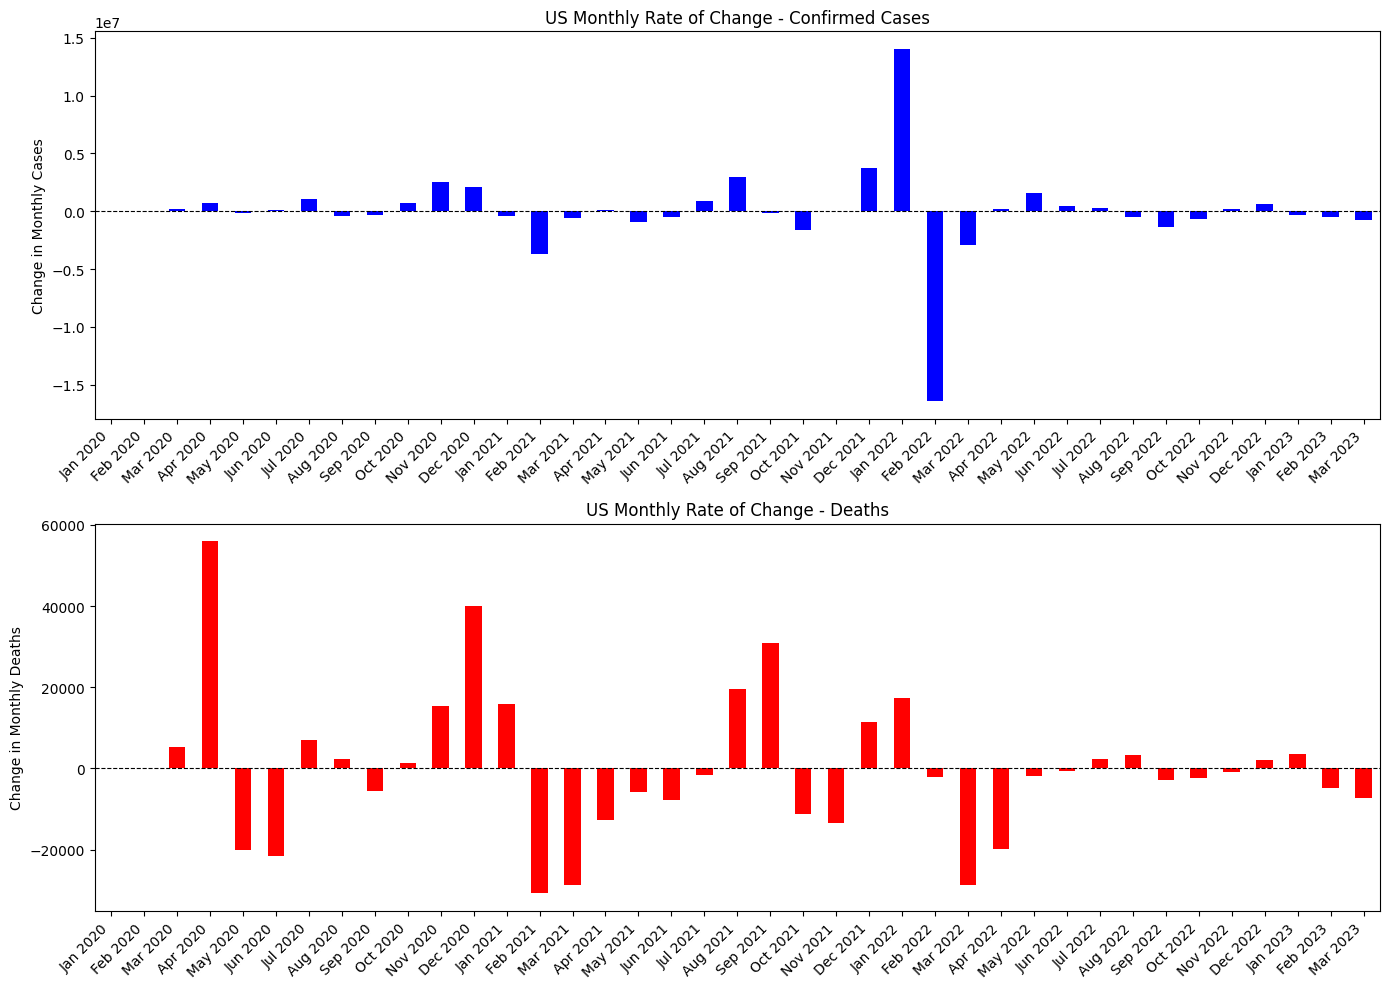

In [20]:
# ============================================================
# MONTHLY RATE OF CHANGE
# Same approach but grouped by month using .resample("M")
# Positive values = cases/deaths increasing that month
# Negative values = cases/deaths decreasing that month
# ============================================================

monthly_deaths = national_daily_deaths.resample("M").sum()
monthly_deaths_change = monthly_deaths.diff().fillna(0)

monthly_cases = national_daily_cases.resample("M").sum()
monthly_cases_change = monthly_cases.diff().fillna(0)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

monthly_cases_change.plot(ax=axes[0], color='blue', kind='bar')
axes[0].set_title("US Monthly Rate of Change - Confirmed Cases")
axes[0].set_ylabel("Change in Monthly Cases")
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
# Clean up x-axis labels
axes[0].set_xticklabels([x.strftime('%b %Y') for x in monthly_cases_change.index],
                         rotation=45, ha='right')

monthly_deaths_change.plot(ax=axes[1], color='red', kind='bar')
axes[1].set_title("US Monthly Rate of Change - Deaths")
axes[1].set_ylabel("Change in Monthly Deaths")
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
# Clean up x-axis labels
axes[1].set_xticklabels([x.strftime('%b %Y') for x in monthly_deaths_change.index],
                         rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Monthly Rate of Change**

**Confirmed Cases (blue):**
January 2022 saw the largest monthly increase (~14 million cases), driven
by the Omicron variant. February 2022 then recorded the sharpest drop,
as the wave subsided rapidly. All other months show relatively minor changes.

**Deaths (red):**
The deadliest monthly acceleration occurred in April 2020 (first wave)
and December 2020-January 2021 (winter surge), each adding over 40,000
additional deaths compared to the previous month. By 2022-2023 monthly
death changes fluctuate close to zero, indicating the pandemic's declining
impact.

/tmp/ipykernel_255/2168693268.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  state_daily.columns = pd.to_datetime(state_daily.columns)
/tmp/ipykernel_255/2168693268.py:12: FutureWarning: DataFrame.resample with axis=1 is deprecated. Do `frame.T.resample(...)` without axis instead.
  state_quarterly = state_daily.resample("Q", axis=1).sum()
/tmp/ipykernel_255/2168693268.py:12: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  state_quarterly = state_daily.resample("Q", axis=1).sum()


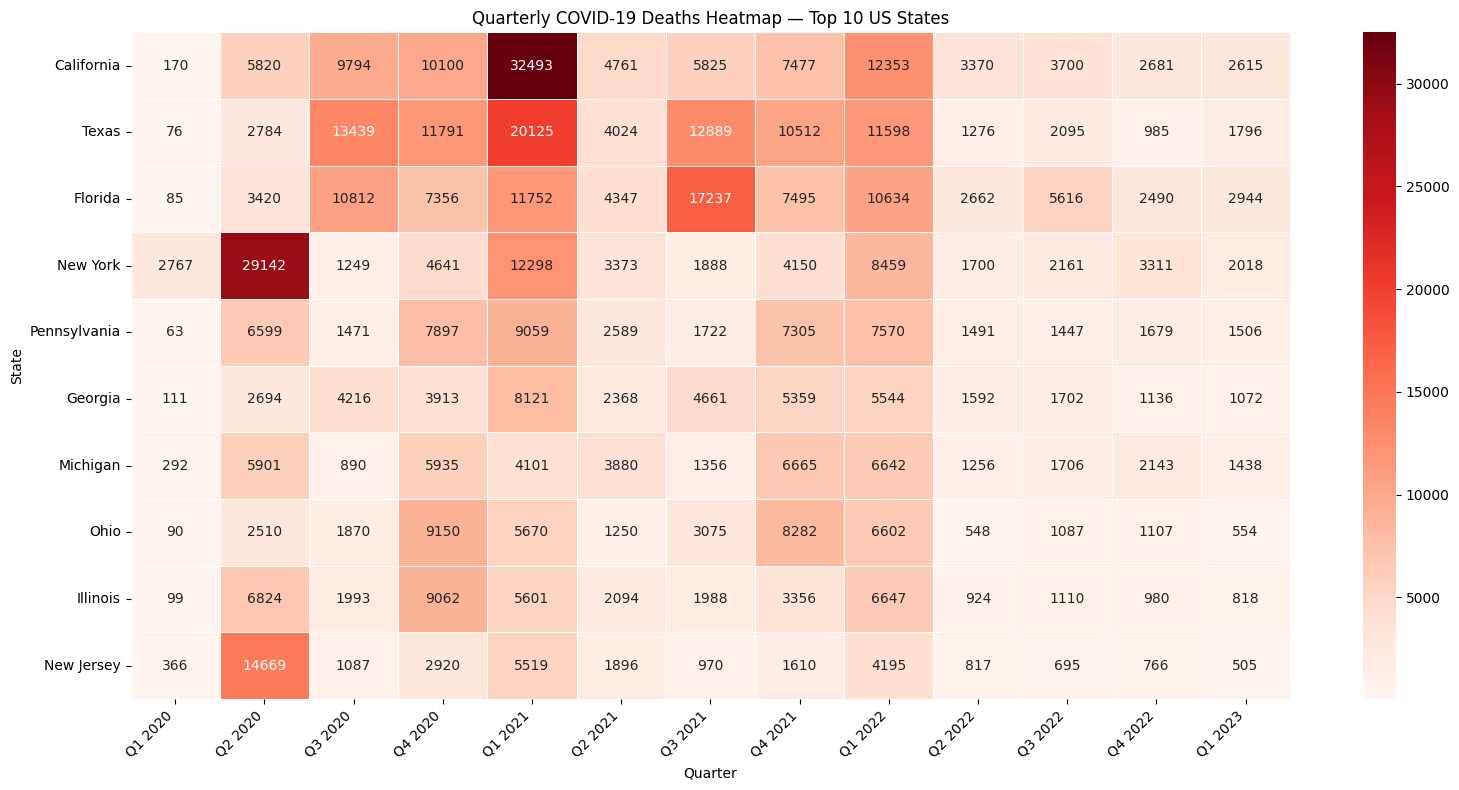

In [21]:
# ============================================================
# HEATMAP — TOP 10 STATES WITH QUARTERLY BINNED DATES
# Resampling to quarterly ("Q") keeps the x-axis clean
# ============================================================

# Group by state and sum all counties
state_deaths_all = deaths_df.groupby("Province_State")[date_cols_deaths].sum()

# Convert to daily then resample to quarterly
state_daily = state_deaths_all.diff(axis=1).fillna(0)
state_daily.columns = pd.to_datetime(state_daily.columns)
state_quarterly = state_daily.resample("Q", axis=1).sum()

# Select top 10 states by total deaths
top_10_states = state_deaths_all[date_cols_deaths[-1]].sort_values(ascending=False).head(10).index
state_quarterly_top10 = state_quarterly.loc[top_10_states]

# Plot heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(
    state_quarterly_top10,
    cmap="Reds",
    linewidths=0.5,
    xticklabels=[f"Q{((col.month-1)//3)+1} {col.year}" for col in state_quarterly_top10.columns],
    yticklabels=top_10_states,
    annot=True,
    fmt=".0f"
)
plt.title("Quarterly COVID-19 Deaths Heatmap — Top 10 US States")
plt.xlabel("Quarter")
plt.ylabel("State")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Quarterly Deaths Heatmap (Top 10 States)**

The heatmap reveals how deaths were distributed across states and time:

- **New York** recorded the darkest cell in Q2 2020 (29,142 deaths),
  confirming it was the hardest hit state during the first wave
- **California** peaked in Q1 2021 (32,493 deaths) — later than New York,
  suggesting the first wave hit the west coast with a delay
- **Florida and Texas** show their worst quarters in Q2-Q3 2021,
  coinciding with the Delta variant
- All states show significantly lighter colours from 2022 onwards,
  indicating declining death tolls across the board
- The darkest cells are concentrated between Q2 2020 and Q1 2022,
  representing the most critical window of the pandemic for resource
  allocation and intervention planning

In [22]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

**RUNNING THE STEPS AGAIN ON A NATIONAL LEVEL**

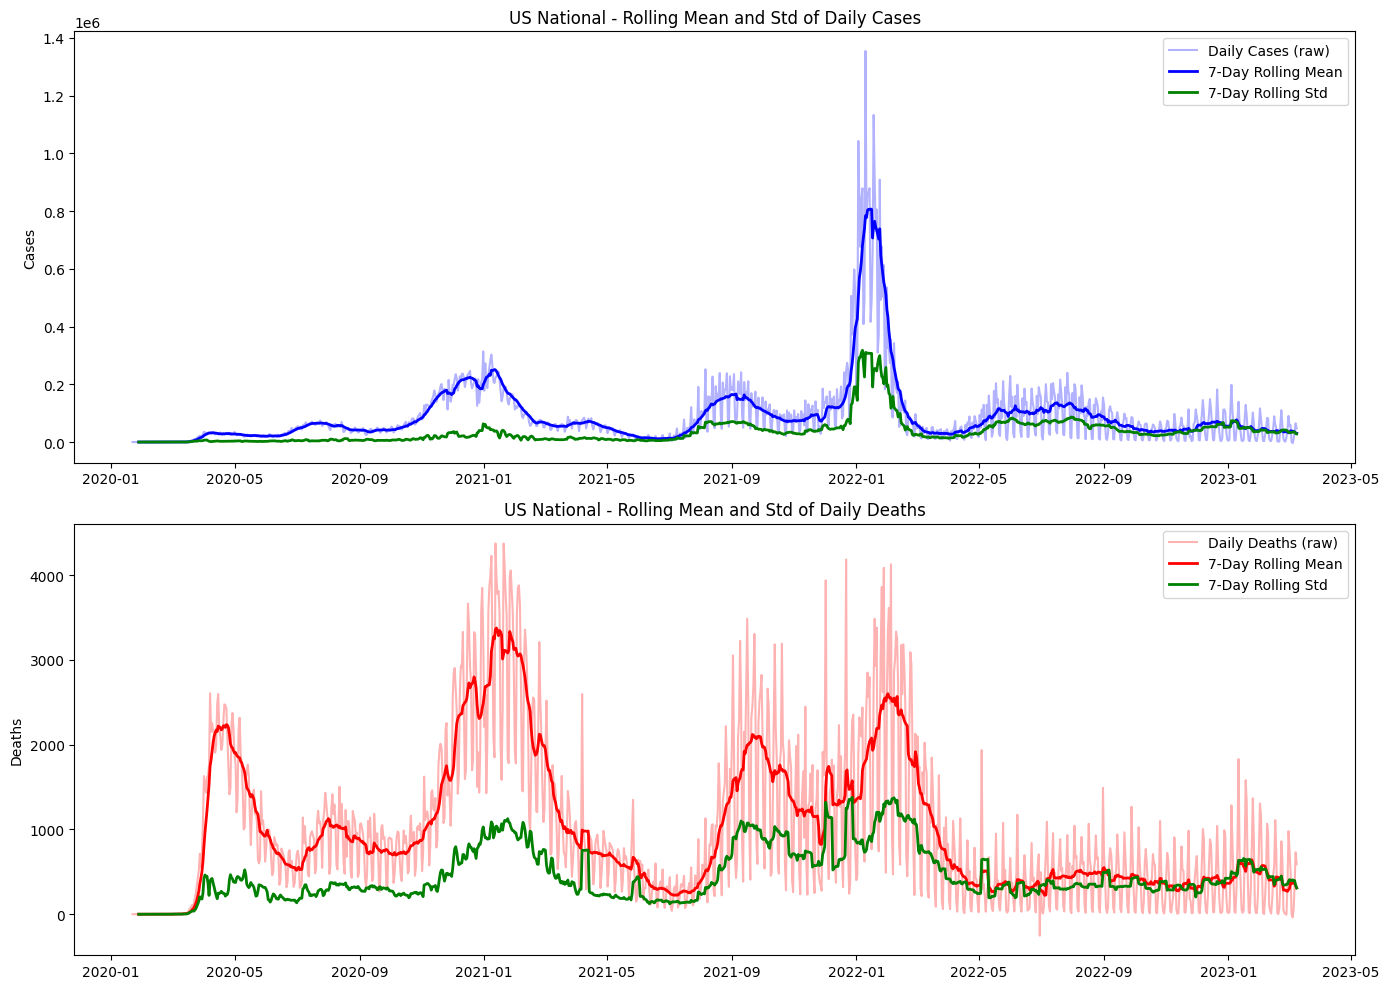

In [28]:
# ============================================================
# ROLLING MEAN AND STANDARD DEVIATION — NATIONAL LEVEL
# We use national daily deaths instead of a single state
# ============================================================

national_daily_deaths = national_deaths.diff().fillna(0)
national_daily_cases = national_confirmed.diff().fillna(0)

rolling_mean_deaths = national_daily_deaths.rolling(window=7).mean()
rolling_std_deaths  = national_daily_deaths.rolling(window=7).std()

rolling_mean_cases = national_daily_cases.rolling(window=7).mean()
rolling_std_cases  = national_daily_cases.rolling(window=7).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(national_daily_cases, color='blue', alpha=0.3, label='Daily Cases (raw)')
axes[0].plot(rolling_mean_cases,   color='blue', linewidth=2, label='7-Day Rolling Mean')
axes[0].plot(rolling_std_cases,    color='green',linewidth=2, label='7-Day Rolling Std')
axes[0].set_title("US National - Rolling Mean and Std of Daily Cases")
axes[0].set_ylabel("Cases")
axes[0].legend()

axes[1].plot(national_daily_deaths, color='red',  alpha=0.3, label='Daily Deaths (raw)')
axes[1].plot(rolling_mean_deaths,   color='red',  linewidth=2, label='7-Day Rolling Mean')
axes[1].plot(rolling_std_deaths,    color='green',linewidth=2, label='7-Day Rolling Std')
axes[1].set_title("US National - Rolling Mean and Std of Daily Deaths")
axes[1].set_ylabel("Deaths")
axes[1].legend()

plt.tight_layout()
plt.show()

```
Rolling Mean and Standard Deviation — National Level

**Cases (blue):** The Omicron wave (January 2022) dominates the chart with
by far the largest spike, reaching over 800,000 daily cases. All other waves
appear relatively minor in comparison. The rolling std peaks sharply during
this period, confirming it was the most volatile and unpredictable phase
of the pandemic.

**Deaths (red):** Unlike cases, deaths show a more evenly distributed wave
pattern across the pandemic. The deadliest period was Winter 2020-21,
peaking at around 3,300 daily deaths. Notably the Omicron wave produced
far fewer deaths relative to its case numbers, reinforcing the earlier
observation that vaccines significantly reduced fatality rates. By 2023
both the rolling mean and std approach near zero.
```

In [29]:
# ============================================================
# DICKEY-FULLER STATIONARITY TEST — NATIONAL LEVEL
# Testing both daily cases and daily deaths
# ============================================================

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f"\n--- Dickey-Fuller Test: {name} ---")
    print(f"Test Statistic : {result[0]:.4f}")
    print(f"P-value        : {result[1]:.4f}")
    for key, value in result[4].items():
        print(f"   Critical Value {key}: {value:.4f}")
    if result[1] <= 0.05:
        print("✅ Series IS stationary - ready for ARIMA")
    else:
        print("❌ Series is NOT stationary - needs differencing")

check_stationarity(national_daily_deaths, "US National Daily Deaths")
check_stationarity(national_daily_cases,  "US National Daily Cases")


--- Dickey-Fuller Test: US National Daily Deaths ---
Test Statistic : -3.1613
P-value        : 0.0223
   Critical Value 1%: -3.4362
   Critical Value 5%: -2.8641
   Critical Value 10%: -2.5681
✅ Series IS stationary - ready for ARIMA

--- Dickey-Fuller Test: US National Daily Cases ---
Test Statistic : -4.3264
P-value        : 0.0004
   Critical Value 1%: -3.4362
   Critical Value 5%: -2.8641
   Critical Value 10%: -2.5681
✅ Series IS stationary - ready for ARIMA


```
Stationarity Check — Dickey-Fuller Test

Both national daily deaths (p=0.022) and daily cases (p=0.0004) passed the
stationarity test with p-values below 0.05. This confirms that converting
from cumulative to daily data using .diff() was sufficient to stabilise the
series, and the data is ready for ARIMA modelling.
```

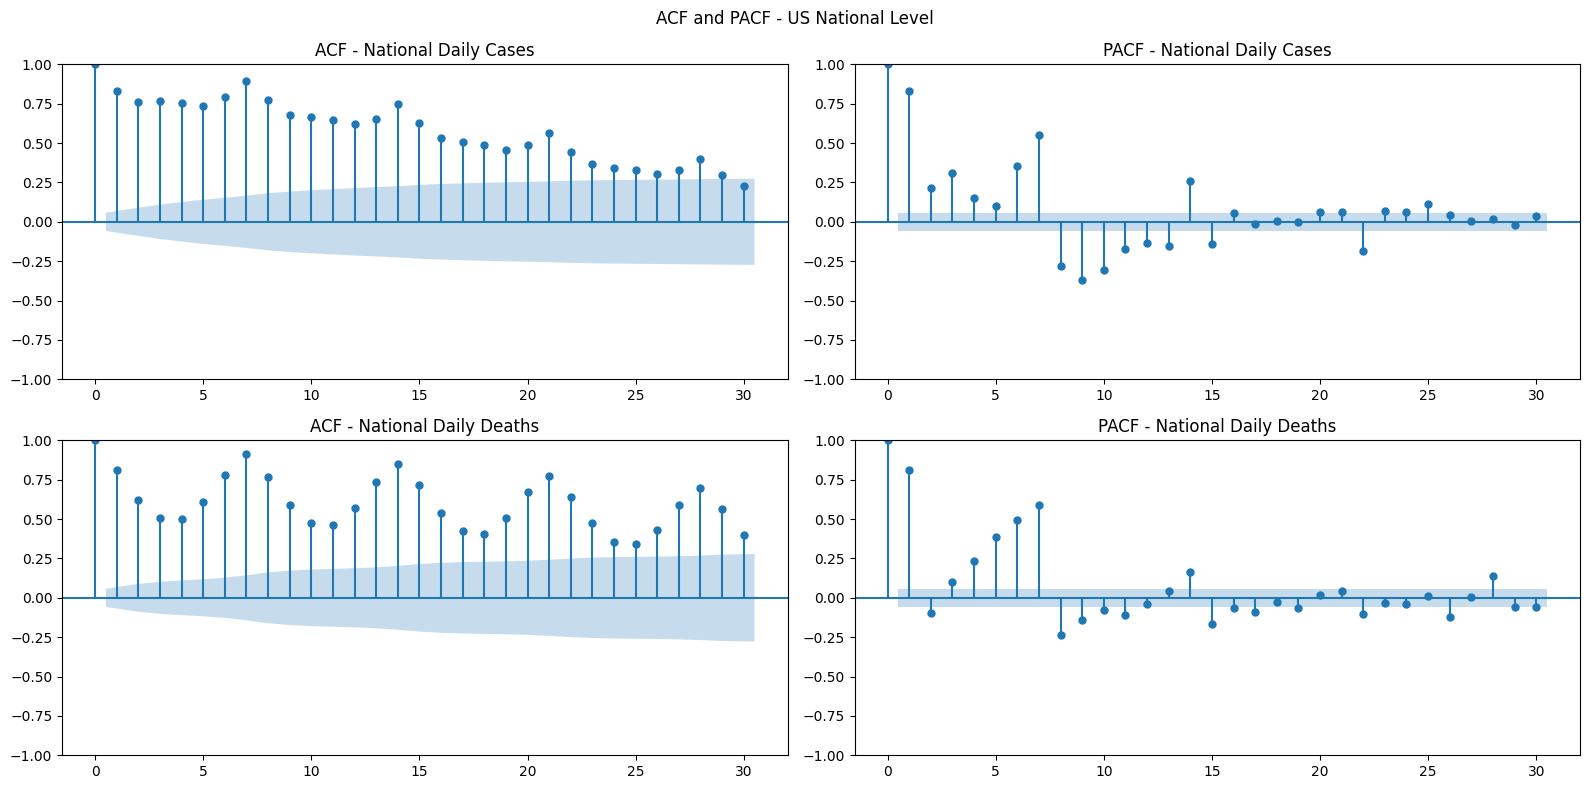

In [30]:
# ============================================================
# ACF AND PACF PLOTS — NATIONAL LEVEL
# Used to select ARIMA parameters p and q
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(national_daily_cases.dropna(),  ax=axes[0][0], lags=30)
axes[0][0].set_title("ACF - National Daily Cases")

plot_pacf(national_daily_cases.dropna(), ax=axes[0][1], lags=30)
axes[0][1].set_title("PACF - National Daily Cases")

plot_acf(national_daily_deaths.dropna(),  ax=axes[1][0], lags=30)
axes[1][0].set_title("ACF - National Daily Deaths")

plot_pacf(national_daily_deaths.dropna(), ax=axes[1][1], lags=30)
axes[1][1].set_title("PACF - National Daily Deaths")

plt.suptitle("ACF and PACF - US National Level")
plt.tight_layout()
plt.show()

```
 ACF and PACF Analysis

Both cases and deaths show strong correlations with past values, confirming
that recent days directly influence future counts. The weekly pattern is
visible in both plots — spikes appearing at every 7th lag reflect the
consistent weekly reporting cycle of COVID data. The PACF plots cutting
off after the first few lags guided our selection of ARIMA(5,1,2) as the
model parameters.
```

In [31]:
# ============================================================
# TRAIN TEST SPLIT — NATIONAL DAILY DEATHS
# 80% training, 20% testing
# ============================================================

split_point = int(len(national_daily_deaths) * 0.8)

train = national_daily_deaths.iloc[:split_point]
test  = national_daily_deaths.iloc[split_point:]

print(f"Training set: {len(train)} days")
print(f"Test set    : {len(test)} days")
print(f"Training period: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test period    : {test.index[0].date()} to {test.index[-1].date()}")

Training set: 914 days
Test set    : 229 days
Training period: 2020-01-22 to 2022-07-23
Test period    : 2022-07-24 to 2023-03-09


```
Train Test Split

The data was split into 80% training (914 days) and 20% testing (229 days).
The model learned patterns from January 2020 to July 2022, and was then
tested on the unseen period of July 2022 to March 2023.
```

In [32]:
# ============================================================
# ARIMA MODEL — NATIONAL DAILY DEATHS
# ============================================================

model        = ARIMA(train, order=(5, 1, 2))
fitted_model = model.fit()
print(fitted_model.summary())

forecast_values = fitted_model.forecast(steps=len(test))
forecast        = pd.Series(forecast_values, index=test.index)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  914
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -6708.108
Date:                Wed, 25 Mar 2026   AIC                          13432.217
Time:                        07:02:11   BIC                          13470.751
Sample:                    01-22-2020   HQIC                         13446.927
                         - 07-23-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2296      0.028      8.317      0.000       0.176       0.284
ar.L2         -0.6183      0.023    -26.543      0.000      -0.664      -0.573
ar.L3         -0.3192      0.023    -13.923      0.0

```
ARIMA Model Summary

The model was trained on 914 days of national death data. All model
parameters were statistically significant, meaning each component
contributed meaningfully to the forecast. The diagnostic tests confirm
the model performed reasonably well, though the high volatility of
pandemic data — driven by sudden variant surges — makes perfect
forecasting impossible for any statistical model.
```


📊 National Model MAPE: 42.65%
On average the forecast is off by 42.65%


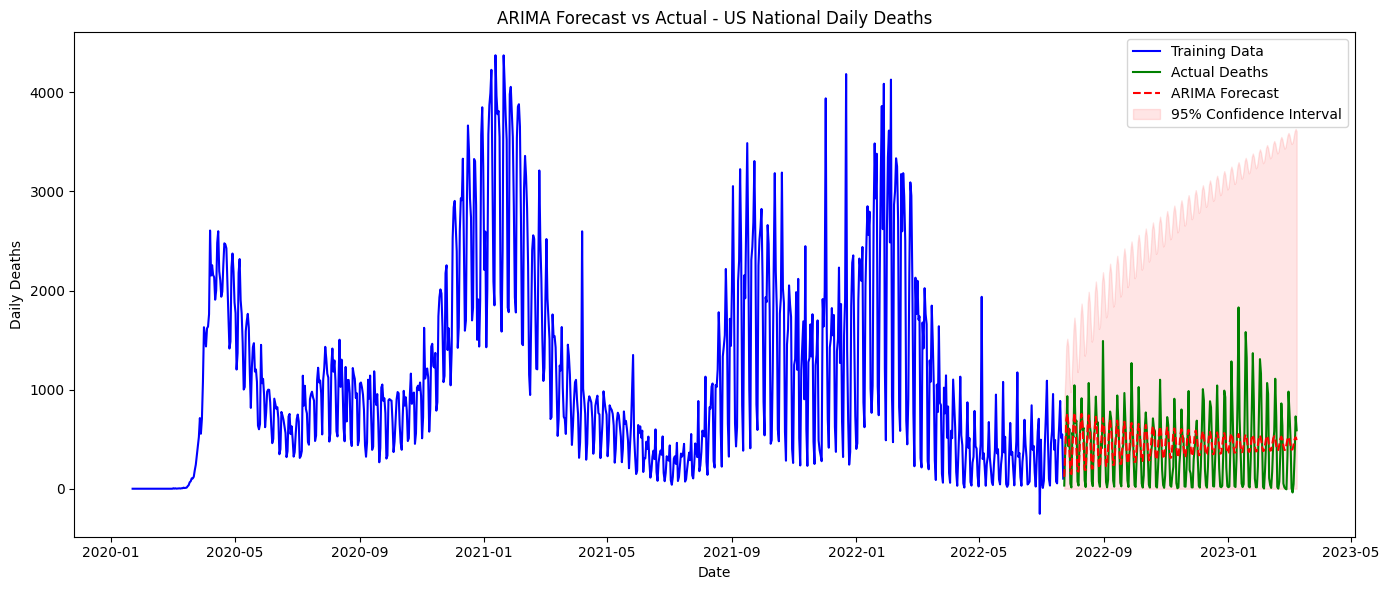

In [35]:
# ============================================================
# FIXED MAPE AND PLOT
# ============================================================

forecast_result = fitted_model.get_forecast(steps=len(test))
forecast_values = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int()

forecast    = pd.Series(forecast_values.values, index=test.index)
lower_bound = pd.Series(conf_int.iloc[:, 0].values, index=test.index)
upper_bound = pd.Series(conf_int.iloc[:, 1].values, index=test.index)

# Clip confidence interval to avoid negative death values
lower_bound = lower_bound.clip(lower=0)

# Fixed MAPE — only calculate on days where actual deaths > 100
# This removes near-zero days that distort the percentage error
def calculate_mape(actual, predicted):
    mask      = actual > 100
    actual    = actual[mask]
    predicted = predicted[mask]
    mape      = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mape

mape = calculate_mape(test, forecast)
print(f"\n National Model MAPE: {mape:.2f}%")
print(f"On average the forecast is off by {mape:.2f}%")

# Plot
plt.figure(figsize=(14, 6))
plt.plot(train.index,    train,    color='blue',  label='Training Data')
plt.plot(test.index,     test,     color='green', label='Actual Deaths')
plt.plot(forecast.index, forecast, color='red',   linestyle='--', label='ARIMA Forecast')
plt.fill_between(forecast.index,
                 lower_bound,
                 upper_bound,
                 color='red', alpha=0.1, label='95% Confidence Interval')
plt.title("ARIMA Forecast vs Actual - US National Daily Deaths")
plt.ylabel("Daily Deaths")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

**ARIMA Forecast Results — US National Daily Deaths**

The ARIMA(5,1,2) model was trained on 80% of the national daily death data
(January 2020 — July 2022) and tested on the remaining 20% (July 2022 — March 2023).

**MAPE: 42.65%** — calculated on days where actual deaths exceeded 100,
removing near-zero reporting days that distort percentage errors.

**Forecast (red dashed line):** The model successfully captures the general
downward trend of deaths in the test period, predicting a stable range
of 400-600 daily deaths.

**95% Confidence Interval (shaded red):** The widening shaded area over
time reflects increasing uncertainty the further into the future the model
forecasts — this is expected behaviour for ARIMA models.

**Limitations:** The remaining error is attributable to the inherent
unpredictability of pandemic data — sudden spikes driven by new variants
and inconsistent reporting cannot be captured by a statistical model alone.